# YOLO 모델별 · augmentation 개수별 객체검출 성능 비교 (Web Cam)

- **목적**: car(검은 장난감 지프) / dummy(검은 LAN-hub 박스) 검출에 맞는 YOLO 모델과 학습 증강 조건 찾기
- **데이터셋**: `../data_wc/rokey_mp4_a1.v2i.yolo26` (Roboflow v2, 640x640, train 444 / valid 43 / test 21)
- **결과 저장 위치**: `./result_detection/` (이 노트북과 같은 폴더)
- **실행 환경**: 로컬 PC (`~/venvs/rokey_venv`, GPU). Colab 전용 코드(drive mount, `cv2_imshow`, `/content/...`)는 제거함

| 실험 | 내용 | 학습 횟수 |
|---|---|---|
| 실험 1 | 모델별 비교: 6개 모델, Ultralytics 기본 증강 | 6 |
| 실험 2 | augmentation 개수별 비교: 6개 모델 x 증강 3조건 (`aug0` / `aug2` / `aug4`) | 18 |

**실행 순서**: 위에서부터 차례대로 실행. 먼저 `QUICK_TEST = True`로 끝까지 한 번 돌려 오류가 없는지 확인한 뒤, `False`로 바꿔 본 실험을 진행한다.
이미 끝난 학습은 건너뛰므로, 중간에 끊겨도 같은 셀을 다시 실행하면 이어서 진행된다.

## 0. 패키지 확인
비교표에 `pandas`, 그래프에 `matplotlib`을 쓴다. 없으면 설치한다 (rokey_venv 커널 기준).

In [1]:
%pip install -q pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.170 🚀 Python-3.12.3 torch-2.14.1+cu130 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 7806MiB)


Setup complete ✅ (22 CPUs, 30.8 GB RAM, 93.3/936.8 GB disk)


## 1. 설정
- ⚠️ **`QUICK_TEST`**: `True`면 1 epoch, 데이터 10%만 써서 코드가 끝까지 도는지만 빠르게 확인한다. 결과는 `result_detection/_quick_test/`에 따로 저장된다.
- ⚠️ **`BATCH`**: 16. 팀원 Colab(Tesla T4, 15GB)은 32였지만, 이 PC(RTX 4070 Laptop, 8GB)에서는 32로 하면 s 모델에서 CUDA out of memory가 난다.
  이때 Ultralytics가 **자동으로 16으로 낮춰 재시도**해서 run마다 batch가 달라지므로(공정한 비교가 안 됨), 처음부터 모든 run을 16으로 통일한다.

In [3]:
import os
import time
import logging
from pathlib import Path

QUICK_TEST = False       # ⚠️ 동작 확인 후 False로 바꿔 본 실험 진행
BATCH = 16               # ⚠️ 8GB GPU 기준. 32는 s 모델에서 메모리 부족 (모든 run 같은 값으로 통일)
EPOCHS = 100
PATIENCE = 20            # 20 epoch 동안 개선이 없으면 조기 종료
IMGSZ = 640

# 모든 표·그래프는 이 순서로 나온다: 최신 버전부터 (같은 버전 안에서는 n → s)
MODEL_LIST = ['yolo26n', 'yolo26s', 'yolo11n', 'yolo11s', 'yolov8n', 'yolov8s']

# 경로 (노트북이 있는 폴더 기준)
NB_DIR = Path.cwd()
DATA_DIR = (NB_DIR / '../data_wc/rokey_mp4_a1.v2i.yolo26').resolve()
RESULT_DIR = NB_DIR / 'result_detection'
if QUICK_TEST:
    RESULT_DIR = RESULT_DIR / '_quick_test'
PRETRAINED_DIR = NB_DIR / 'result_detection' / 'pretrained'   # COCO 사전학습 가중치 (QUICK_TEST와 공유)
LOG_DIR = RESULT_DIR / 'log'
for d in [RESULT_DIR, PRETRAINED_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

assert (DATA_DIR / 'train/images').is_dir(), f'데이터셋 경로 확인: {DATA_DIR}'

# 사전학습 가중치(yolo26s.pt 등)와 AMP 확인용 파일이 노트북 폴더에 흩어지지 않게 작업 폴더를 옮긴다
os.chdir(PRETRAINED_DIR)

# Ultralytics log를 파일로도 남긴다 (학습 과정 기록)
TS = time.strftime('%y%m%d_%H%M%S')
log_path = LOG_DIR / f'log_{TS}.txt'
ul_logger = logging.getLogger('ultralytics')
ul_logger.addHandler(logging.FileHandler(log_path, encoding='utf-8'))

print('QUICK_TEST :', QUICK_TEST)
print('DATA_DIR   :', DATA_DIR)
print('RESULT_DIR :', RESULT_DIR)
print('log        :', log_path)

QUICK_TEST : False
DATA_DIR   : /home/mu-01/ROKEY_mP4_A1/rokey_ws/src/wc/data_wc/rokey_mp4_a1.v2i.yolo26
RESULT_DIR : /home/mu-01/ROKEY_mP4_A1/rokey_ws/src/wc/03_YOLO_v8_object_detection/result_detection
log        : /home/mu-01/ROKEY_mP4_A1/rokey_ws/src/wc/03_YOLO_v8_object_detection/result_detection/log/log_261004_124707.txt


## 2. 데이터셋 yaml 만들기
Roboflow의 `data.yaml`은 상대 경로(`../train/images`)라서, 절대 경로로 된 `custom_data.yaml`을 `result_detection/`에 새로 만든다.

In [4]:
import yaml

with open(DATA_DIR / 'data.yaml') as f:
    roboflow_yaml = yaml.safe_load(f)

data = {
    'train': str(DATA_DIR / 'train/images'),
    'val': str(DATA_DIR / 'valid/images'),
    'test': str(DATA_DIR / 'test/images'),
    'nc': roboflow_yaml['nc'],
    'names': roboflow_yaml['names'],
}
DATA_YAML = RESULT_DIR / 'custom_data.yaml'
with open(DATA_YAML, 'w') as f:
    yaml.dump(data, f, allow_unicode=True)

print(open(DATA_YAML).read())

names:
- car
- dummy
nc: 2
test: /home/mu-01/ROKEY_mP4_A1/rokey_ws/src/wc/data_wc/rokey_mp4_a1.v2i.yolo26/test/images
train: /home/mu-01/ROKEY_mP4_A1/rokey_ws/src/wc/data_wc/rokey_mp4_a1.v2i.yolo26/train/images
val: /home/mu-01/ROKEY_mP4_A1/rokey_ws/src/wc/data_wc/rokey_mp4_a1.v2i.yolo26/valid/images



## 3. 데이터 확인
split별 이미지 수와 class별 객체 수, 그리고 train 이미지 몇 장을 라벨 박스와 함께 본다.

train: 이미지 444장, 객체 {'car': 369, 'dummy': 375}
valid: 이미지  43장, 객체 {'car': 36, 'dummy': 35}
test : 이미지  21장, 객체 {'car': 21, 'dummy': 16}


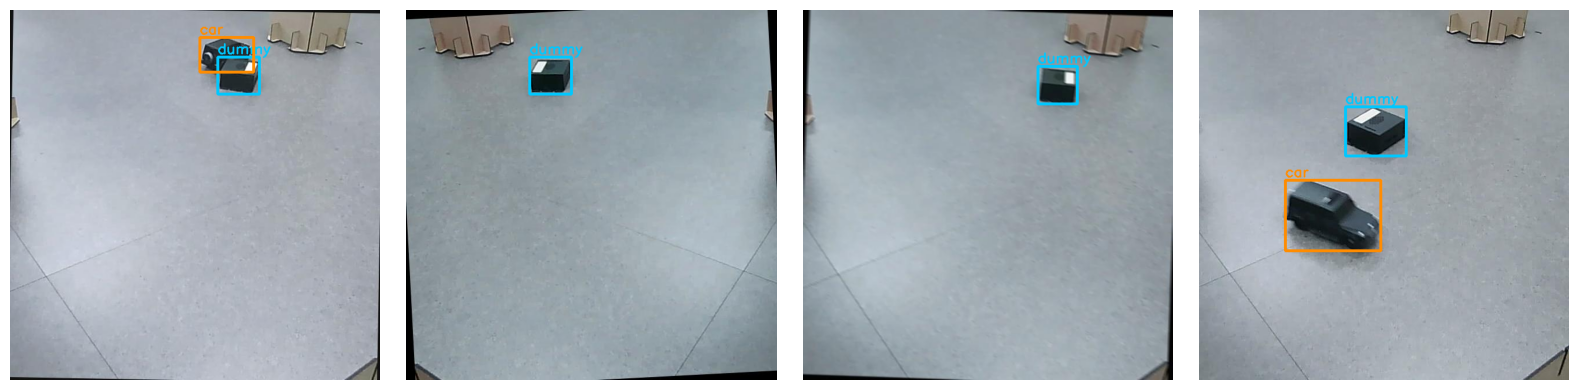

In [5]:
%matplotlib inline
import random
import cv2
import matplotlib.pyplot as plt

names = data['names']
for split in ['train', 'valid', 'test']:
    images = sorted((DATA_DIR / split / 'images').glob('*.jpg'))
    counts = {n: 0 for n in names}
    for img in images:
        label = DATA_DIR / split / 'labels' / (img.stem + '.txt')
        for line in label.read_text().splitlines():
            if line.strip():
                counts[names[int(line.split()[0])]] += 1
    print(f'{split:5s}: 이미지 {len(images):3d}장, 객체 {counts}')

# train 이미지 4장을 라벨 박스와 함께 표시
samples = random.sample(sorted((DATA_DIR / 'train/images').glob('*.jpg')), 4)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img_path in zip(axes, samples):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    label = DATA_DIR / 'train/labels' / (img_path.stem + '.txt')
    for line in label.read_text().splitlines():
        if not line.strip():
            continue
        c, cx, cy, bw, bh = map(float, line.split())
        x1, y1 = int((cx - bw / 2) * w), int((cy - bh / 2) * h)
        x2, y2 = int((cx + bw / 2) * w), int((cy + bh / 2) * h)
        color = (255, 140, 0) if names[int(c)] == 'car' else (0, 200, 255)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
        cv2.putText(img, names[int(c)], (x1, max(y1 - 6, 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. 공통 함수
- `train_run()`: 학습 1회. 결과 폴더가 이미 있고 `weights/best.pt`가 있으면 건너뛴다 (중간에 끊겨도 이어서 실행 가능)
- `evaluate()`: `best.pt`로 **valid 데이터를 같은 조건으로 다시 평가**하고, `results.csv`에서 epoch 수와 학습 시간을 읽는다

In [6]:
import gc
import torch
import pandas as pd
from ultralytics import YOLO


def train_run(model_name, project_dir, run_name, **train_args):
    # 학습 1회. 이미 끝난 run은 건너뛰고 best.pt 경로를 돌려준다.
    best = project_dir / run_name / 'weights' / 'best.pt'
    if best.exists():
        print('이미 완료, 건너뜀:', run_name)
        return best

    print('========== 학습 시작:', run_name)
    model = YOLO(model_name + '.pt')        # PRETRAINED_DIR에 없으면 자동 다운로드
    args = dict(data=str(DATA_YAML), epochs=EPOCHS, patience=PATIENCE, batch=BATCH, imgsz=IMGSZ,
                project=str(project_dir), name=run_name, exist_ok=True)
    if QUICK_TEST:
        args.update(epochs=1, fraction=0.1)
    args.update(train_args)
    model.train(**args)

    # 다음 학습 전에 GPU 메모리 정리
    del model
    gc.collect()
    torch.cuda.empty_cache()
    print('저장 완료:', run_name)
    return best


def evaluate(best_path, run_dir, **extra):
    # best.pt로 valid를 다시 평가하고 비교표 한 줄을 만든다.
    model = YOLO(str(best_path))
    metrics = model.val(data=str(DATA_YAML), imgsz=IMGSZ, batch=BATCH, split='val',
                        project=str(run_dir), name='val_best', exist_ok=True, plots=False)
    precision, recall = metrics.box.mp, metrics.box.mr
    f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0.0

    history = pd.read_csv(run_dir / 'results.csv')
    row = dict(extra)
    row.update({
        'epochs': len(history),
        'train_min': round(history['time'].iloc[-1] / 60, 1),
        'precision': round(precision, 3),
        'recall': round(recall, 3),
        'F1': round(f1, 3),
        'mAP50': round(metrics.box.map50, 3),
        'mAP50-95': round(metrics.box.map, 3),
        'inference_ms': round(metrics.speed['inference'], 1),
    })
    del model
    gc.collect()
    torch.cuda.empty_cache()
    return row

## 5. 실험 1 — 모델별 비교 (Ultralytics 기본 증강)
결과: `result_detection/exp1_models/<모델>/` (학습 그래프, confusion matrix, `weights/best.pt`, `results.csv`)

In [7]:
EXP1_DIR = RESULT_DIR / 'exp1_models'

for model_name in MODEL_LIST:
    train_run(model_name, EXP1_DIR, model_name)

이미 완료, 건너뜀: yolo26n
이미 완료, 건너뜀: yolo26s
이미 완료, 건너뜀: yolo11n
이미 완료, 건너뜀: yolo11s
이미 완료, 건너뜀: yolov8n
이미 완료, 건너뜀: yolov8s


========== 평가: yolo26n
Ultralytics 8.4.170 🚀 Python-3.12.3 torch-2.14.1+cu130 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 7806MiB)


YOLO26n summary (fused): 120 layers, 2,375,226 parameters, 0 gradients, 5.3 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2850.3±699.2 MB/s, size: 24.6 KB)


val: Scanning /home/mu-01/ROKEY_mP4_A1/rokey_ws/src/wc/data_wc/rokey_mp4_a1.v2i.yolo26/valid/labels.cache... 43 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 43/43 12.0Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 33% ━━━━──────── 1/3 1.2it/s 0.3s<1.7s

...

                   all         43         71      0.997      0.999      0.995      0.939


                   car         36         36          1      0.999      0.995      0.909


                 dummy         35         35      0.994          1      0.995      0.969


Speed: 0.4ms preprocess, 5.4ms inference, 0.0ms loss, 0.4ms postprocess per image


,model,epochs,train_min,precision,recall,F1,mAP50,mAP50-95,inference_ms
0,yolo26n,100,4.5,0.982,1.000,0.991,0.995,0.945,2.7
1,yolo26s,48,4.1,0.995,1.000,0.998,0.995,0.921,5.6
2,yolo11n,47,1.8,0.992,0.986,0.989,0.995,0.914,2.3
3,yolo11s,66,4.9,0.998,1.000,0.999,0.995,0.932,5.6
4,yolov8n,62,2.2,0.993,0.999,0.996,0.995,0.931,2.2
5,yolov8s,71,5.1,0.997,0.999,0.998,0.995,0.939,5.4


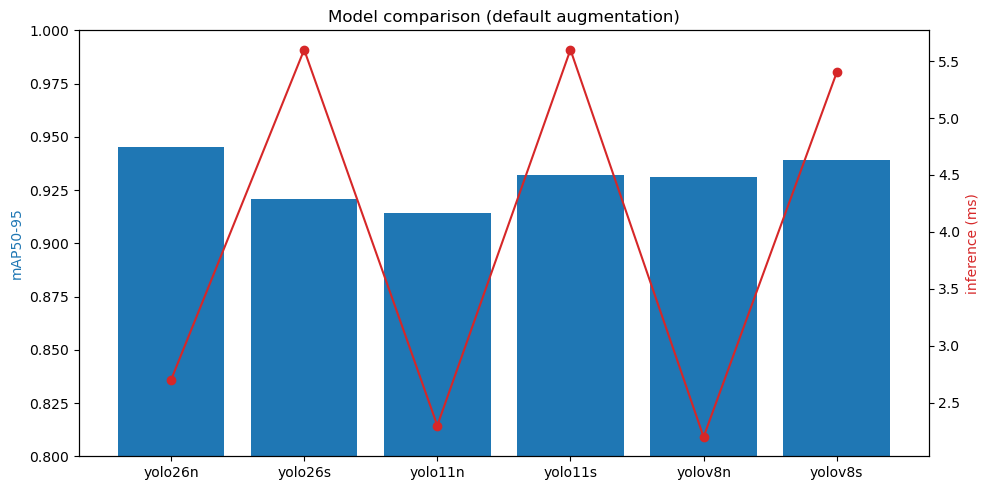

저장: /home/mu-01/ROKEY_mP4_A1/rokey_ws/src/wc/03_YOLO_v8_object_detection/result_detection/compare_models.csv


In [8]:
# 첫 번째로 평가하는 모델만 inference 시간이 길게 나오지 않게 GPU를 미리 예열한다
YOLO(str(EXP1_DIR / MODEL_LIST[0] / 'weights' / 'best.pt')).predict(
    source=str(DATA_DIR / 'valid/images'), imgsz=IMGSZ, verbose=False)

rows = []
for model_name in MODEL_LIST:
    print('========== 평가:', model_name)
    best = EXP1_DIR / model_name / 'weights' / 'best.pt'
    rows.append(evaluate(best, EXP1_DIR / model_name, model=model_name))

table1 = pd.DataFrame(rows)
display(table1)
table1.to_csv(RESULT_DIR / 'compare_models.csv', index=False)

# mAP50-95와 inference 시간 그래프
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(table1['model'], table1['mAP50-95'], color='tab:blue')
ax1.set_ylabel('mAP50-95', color='tab:blue')
ax1.set_ylim(0.8, 1.0)
ax2 = ax1.twinx()
ax2.plot(table1['model'], table1['inference_ms'], 'o-', color='tab:red')
ax2.set_ylabel('inference (ms)', color='tab:red')
plt.title('Model comparison (default augmentation)')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'compare_models.png')
plt.show()
print('저장:', RESULT_DIR / 'compare_models.csv')

## 6. 실험 2 — augmentation 개수별 비교
켜는 증강의 **개수**를 0개 / 2개 / 4개로 바꿔 가며 비교한다. 나머지 증강은 모든 조건에서 끈다.

| 조건 | 켜는 증강 | 개수 |
|---|---|---|
| `aug0` | 없음 | 0 |
| `aug2` | mosaic, hsv_v(밝기) | 2 |
| `aug4` | mosaic, hsv_v(밝기), translate(이동), scale(크기) | 4 |

> 참고: 데이터셋 자체에 Roboflow 증강(좌우 반전, 회전 ±5°, 밝기 ±15%, blur, 원본당 3장)이 이미 들어가 있다.
> 여기서 비교하는 것은 그 위에 **학습 중에 추가로 거는 증강(Ultralytics)** 의 개수다.

결과: `result_detection/exp2_aug/<모델>_<조건>/`

In [9]:
EXP2_DIR = RESULT_DIR / 'exp2_aug'

# 증강 조건 (0.0 = 끔)
AUG_SETTINGS = {
    'aug0': {'mosaic': 0.0, 'hsv_v': 0.0, 'translate': 0.0, 'scale': 0.0},
    'aug2': {'mosaic': 1.0, 'hsv_v': 0.4, 'translate': 0.0, 'scale': 0.0},
    'aug4': {'mosaic': 1.0, 'hsv_v': 0.4, 'translate': 0.1, 'scale': 0.5},
}
# 아래 증강은 모든 조건에서 끔
AUG_OFF = dict(fliplr=0.0, flipud=0.0, hsv_h=0.0, hsv_s=0.0, degrees=0.0, shear=0.0,
               perspective=0.0, mixup=0.0, copy_paste=0.0)

for model_name in MODEL_LIST:
    for aug_name, aug in AUG_SETTINGS.items():
        train_run(model_name, EXP2_DIR, f'{model_name}_{aug_name}', **aug, **AUG_OFF)

이미 완료, 건너뜀: yolo26n_aug0
이미 완료, 건너뜀: yolo26n_aug2
이미 완료, 건너뜀: yolo26n_aug4
이미 완료, 건너뜀: yolo26s_aug0
이미 완료, 건너뜀: yolo26s_aug2
이미 완료, 건너뜀: yolo26s_aug4
이미 완료, 건너뜀: yolo11n_aug0
이미 완료, 건너뜀: yolo11n_aug2
이미 완료, 건너뜀: yolo11n_aug4
이미 완료, 건너뜀: yolo11s_aug0
이미 완료, 건너뜀: yolo11s_aug2
이미 완료, 건너뜀: yolo11s_aug4
이미 완료, 건너뜀: yolov8n_aug0
이미 완료, 건너뜀: yolov8n_aug2
이미 완료, 건너뜀: yolov8n_aug4
이미 완료, 건너뜀: yolov8s_aug0
이미 완료, 건너뜀: yolov8s_aug2
이미 완료, 건너뜀: yolov8s_aug4


========== 평가: yolo26n_aug0
Ultralytics 8.4.170 🚀 Python-3.12.3 torch-2.14.1+cu130 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 7806MiB)


YOLO26n summary (fused): 120 layers, 2,375,226 parameters, 0 gradients, 5.3 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2992.8±744.5 MB/s, size: 25.2 KB)


val: Scanning /home/mu-01/ROKEY_mP4_A1/rokey_ws/src/wc/data_wc/rokey_mp4_a1.v2i.yolo26/valid/labels.cache... 43 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 43/43 25.8Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 33% ━━━━──────── 1/3 1.3it/s 0.2s<1.5s

...

                   car         36         36      0.998          1      0.995      0.902


                 dummy         35         35      0.996          1      0.995       0.97


Speed: 0.4ms preprocess, 5.7ms inference, 0.0ms loss, 0.4ms postprocess per image


,model,aug,epochs,train_min,precision,recall,F1,mAP50,mAP50-95,inference_ms
0,yolo26n,aug0,38,1.7,0.996,0.986,0.991,0.995,0.922,2.3
1,yolo26n,aug2,100,4.5,0.996,0.986,0.991,0.995,0.938,2.1
2,yolo26n,aug4,55,2.5,0.994,1.000,0.997,0.995,0.938,2.3
3,yolo26s,aug0,38,3.2,0.985,0.993,0.989,0.994,0.907,6.2
4,yolo26s,aug2,100,8.5,0.998,1.000,0.999,0.995,0.943,5.3
5,yolo26s,aug4,100,8.5,0.996,1.000,0.998,0.995,0.946,5.2
6,yolo11n,aug0,76,2.9,0.994,0.985,0.989,0.995,0.931,2.4
7,yolo11n,aug2,100,3.8,0.989,1.000,0.994,0.995,0.936,2.7
8,yolo11n,aug4,51,2.0,0.995,0.986,0.990,0.995,0.917,2.7
9,yolo11s,aug0,56,4.1,0.989,0.998,0.994,0.995,0.913,5.3


aug,aug0,aug2,aug4
model,,,
yolo26n,0.922,0.938,0.938
yolo26s,0.907,0.943,0.946
yolo11n,0.931,0.936,0.917
yolo11s,0.913,0.931,0.921
yolov8n,0.931,0.928,0.940
yolov8s,0.908,0.933,0.936


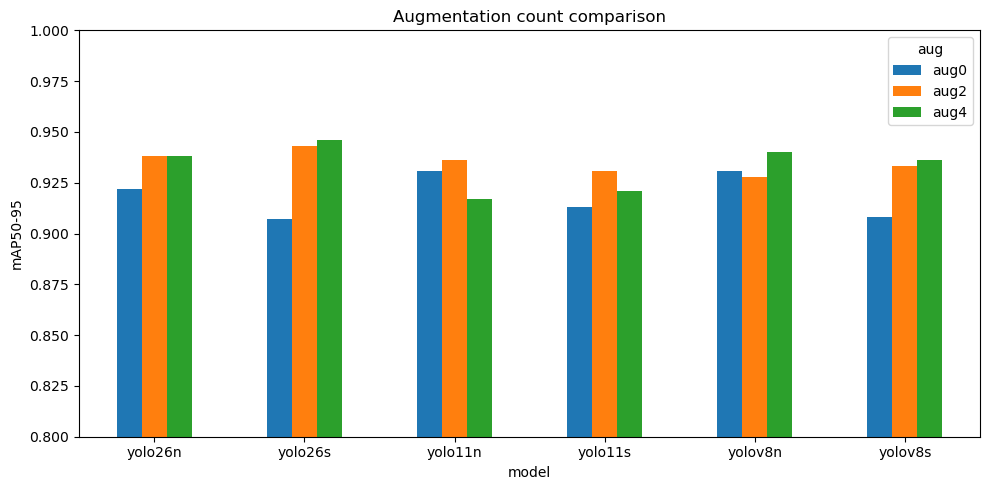

저장: /home/mu-01/ROKEY_mP4_A1/rokey_ws/src/wc/03_YOLO_v8_object_detection/result_detection/compare_aug.csv


In [10]:
rows = []
for model_name in MODEL_LIST:
    for aug_name in AUG_SETTINGS:
        run_name = f'{model_name}_{aug_name}'
        print('========== 평가:', run_name)
        best = EXP2_DIR / run_name / 'weights' / 'best.pt'
        rows.append(evaluate(best, EXP2_DIR / run_name, model=model_name, aug=aug_name))

# 1) 전체 표
table2 = pd.DataFrame(rows)
display(table2)
table2.to_csv(RESULT_DIR / 'compare_aug.csv', index=False)

# 2) 모델 x 증강 조건 표 (mAP50-95)
pivot = table2.pivot(index='model', columns='aug', values='mAP50-95').reindex(MODEL_LIST)
display(pivot)
pivot.to_csv(RESULT_DIR / 'compare_aug_map.csv')

# 3) 막대 그래프
pivot.plot(kind='bar', figsize=(10, 5), ylim=(0.8, 1.0), rot=0)
plt.ylabel('mAP50-95')
plt.title('Augmentation count comparison')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'compare_aug_map.png')
plt.show()
print('저장:', RESULT_DIR / 'compare_aug.csv')

## 7. test 이미지 검출 결과 확인
비교 결과를 보고 확인할 모델을 고른 뒤, test 이미지(21장)에 검출 결과를 그려 저장한다.
결과: `result_detection/predict_test/<run>/`

image 1/21 /home/mu-01/ROKEY_mP4_A1/rokey_ws/src/wc/data_wc/rokey_mp4_a1.v2i.yolo26/test/images/2026-10-02-115344_2_jpg.rf.2e5ac2a54d3fcd1eba77d070a36dce76.jpg: 640x640 1 car, 3.8ms


image 2/21 /home/mu-01/ROKEY_mP4_A1/rokey_ws/src/wc/data_wc/rokey_mp4_a1.v2i.yolo26/test/images/2026-10-02-115733_2_jpg.rf.f4184cb23ec5b25529855c962f2c9986.jpg: 640x640 1 car, 5.1ms


image 3/21 /home/mu-01/ROKEY_mP4_A1/rokey_ws/src/wc/data_wc/rokey_mp4_a1.v2i.yolo26/test/images/2026-10-02-115733_4_jpg.rf.bfeca087e87a9968f965e459c45e1f4c.jpg: 640x640 1 car, 4.8ms


image 4/21 /home/mu-01/ROKEY_mP4_A1/rokey_ws/src/wc/data_wc/rokey_mp4_a1.v2i.yolo26/test/images/2026-10-02-120511_jpg.rf.8c62fd05dc7c5fda2e1407f74448c1c8.jpg: 640x640 1 car, 1 dummy, 4.2ms


image 5/21 /home/mu-01/ROKEY_mP4_A1/rokey_ws/src/wc/data_wc/rokey_mp4_a1.v2i.yolo26/test/images/2026-10-02-120644_jpg.rf.f6d55391a791f2f689d309ce667757a2.jpg: 640x640 1 car, 1 dummy, 4.2ms


...

image 20/21 /home/mu-01/ROKEY_mP4_A1/rokey_ws/src/wc/data_wc/rokey_mp4_a1.v2i.yolo26/test/images/2026-10-02-121412_jpg.rf.2d84cfb62a1f11fade5645558e6b6ced.jpg: 640x640 1 car, 1 dummy, 4.5ms


image 21/21 /home/mu-01/ROKEY_mP4_A1/rokey_ws/src/wc/data_wc/rokey_mp4_a1.v2i.yolo26/test/images/2026-10-02-121413_jpg.rf.8bab18a446b293de4232a2527effca4d.jpg: 640x640 1 car, 1 dummy, 4.2ms


Speed: 0.5ms preprocess, 4.4ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


Results saved to /home/mu-01/ROKEY_mP4_A1/rokey_ws/src/wc/03_YOLO_v8_object_detection/result_detection/predict_test/yolo26s


저장: /home/mu-01/ROKEY_mP4_A1/rokey_ws/src/wc/03_YOLO_v8_object_detection/result_detection/predict_test/yolo26s


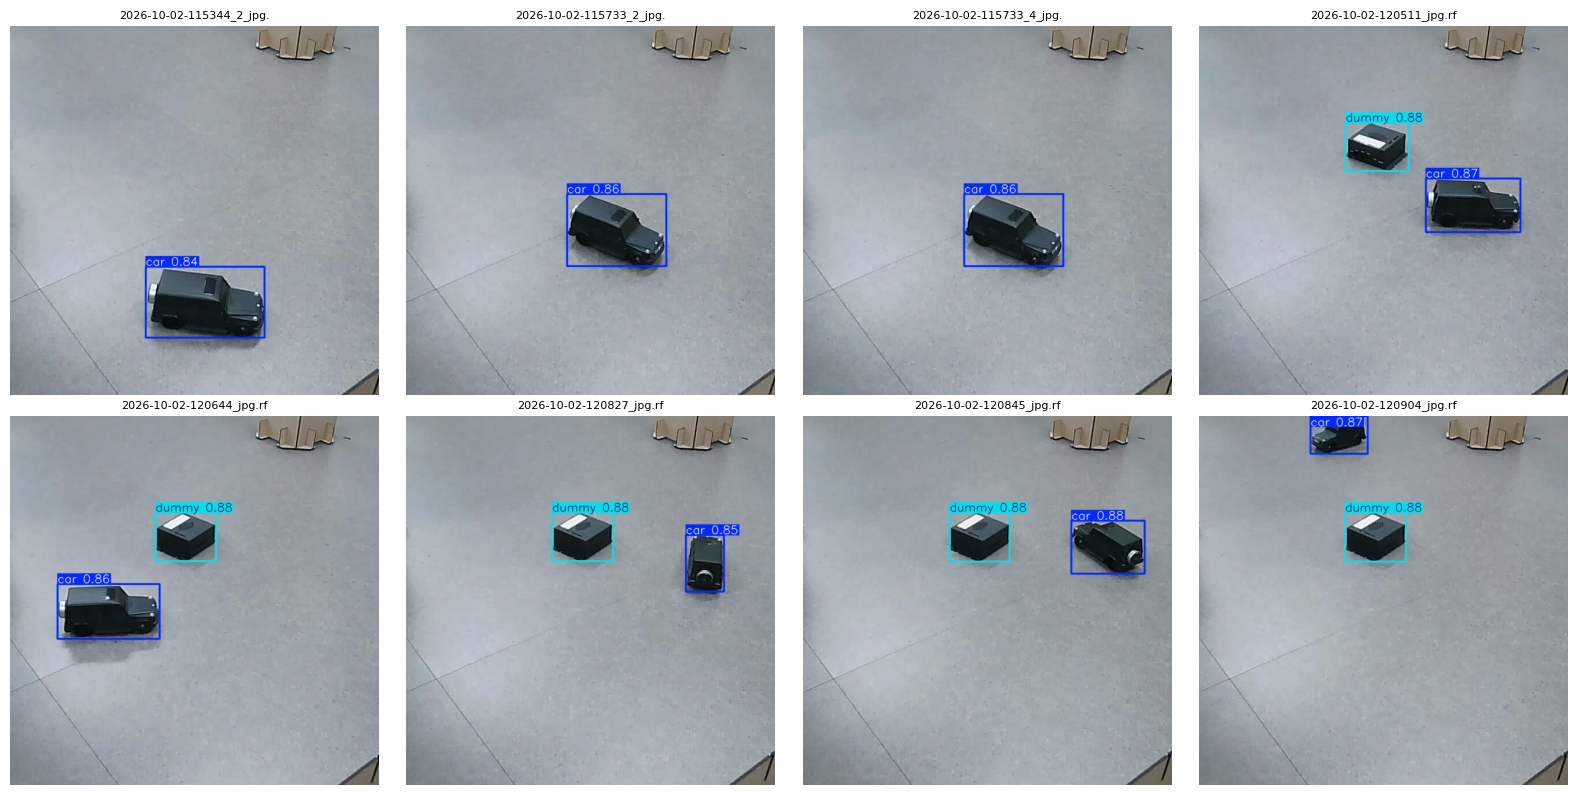

In [11]:
# ⚠️ 확인할 모델 경로를 바꿀 것 (예: EXP2_DIR / 'yolo26s_aug4')
CHECK_RUN = EXP1_DIR / 'yolo26s'

model = YOLO(str(CHECK_RUN / 'weights' / 'best.pt'))
pred = model.predict(source=str(DATA_DIR / 'test/images'), save=True, conf=0.25,
                     project=str(RESULT_DIR / 'predict_test'), name=CHECK_RUN.name, exist_ok=True)
pred_dir = Path(pred[0].save_dir)
print('저장:', pred_dir)

# 저장된 결과 중 8장 표시
images = sorted(pred_dir.glob('*.jpg'))[:8]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, p in zip(axes.flat, images):
    ax.imshow(cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB))
    ax.set_title(p.name[:24], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 8. Test 고정 기준 집계 + 처리 시간 측정 (24개 run)
AMR Cam 팀의 비교 기준과 같게 맞춘다.
- **Test 집계**: `conf=0.25`, NMS `iou=0.7`, **같은 class의 정답과 IoU≥0.5 일대일 매칭** → class별 TP / FP / FN
- **처리 시간**: 첫 test 이미지로 5회 워밍업 → test 21장 전체를 3회 반복 (batch 1, 표본 63개). 전처리 / 추론 / 후처리를 따로 기록
- **운용 기준 참고 집계**: 웹캠 publisher가 쓰는 `conf=0.8`에서 car 미검출(`car_FN_conf08`)과 오검출(`FP_conf08`)
- **최적 epoch**: `results.csv`에서 mAP50-95(Ultralytics fitness)가 처음 최고가 된 epoch, **실제 optimizer**: 학습 log의 `optimizer:` 줄

결과: `result_detection/test_eval/` (`final_comparison.csv`, `test_detections.csv`, `speed_samples.csv`)

log에서 찾은 optimizer 줄: 24 / {'AdamW(lr=0.001667, momentum=0.9)'}


Ultralytics 8.4.170 🚀 Python-3.12.3 torch-2.14.1+cu130 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 7806MiB)


YOLO26n summary (fused): 120 layers, 2,375,226 parameters, 0 gradients, 5.3 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2479.2±414.4 MB/s, size: 25.0 KB)


val: Scanning /home/mu-01/ROKEY_mP4_A1/rokey_ws/src/wc/data_wc/rokey_mp4_a1.v2i.yolo26/test/labels.cache... 21 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 21/21 14.7Mit/s 0.0s

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 7.5it/s 0.3s

                   all         21         37      0.997          1      0.995      0.929


Speed: 0.4ms preprocess, 5.2ms inference, 0.0ms loss, 0.4ms postprocess per image


yolov8s_aug4     best_ep  90 | TP/FP/FN 37/0/0 | inf 3.66 ms


,exp,model,aug,run,optimizer,best_epoch,last_epoch,train_min,val_mAP50,val_mAP50_95,...,dummy_FN,car_FN_conf08,FP_conf08,tp_conf_mean,inf_mean,inf_std,inf_p95,pre_mean,post_mean,total_mean
0,exp1,yolo26n,default,yolo26n,"AdamW(lr=0.001667, momentum=0.9)",82,100,4.49,0.9947,0.9506,...,0,0,0,0.9573,3.853,0.172,4.143,0.366,0.525,4.744
1,exp1,yolo26s,default,yolo26s,"AdamW(lr=0.001667, momentum=0.9)",28,48,4.05,0.9950,0.9242,...,0,0,0,0.8670,3.816,0.159,4.129,0.365,0.531,4.712
2,exp1,yolo11n,default,yolo11n,"AdamW(lr=0.001667, momentum=0.9)",27,47,1.82,0.9947,0.9164,...,0,0,0,0.9133,3.187,0.126,3.431,0.354,0.516,4.057
3,exp1,yolo11s,default,yolo11s,"AdamW(lr=0.001667, momentum=0.9)",46,66,4.87,0.9943,0.9326,...,0,0,0,0.8996,3.498,0.103,3.665,0.364,0.524,4.385
4,exp1,yolov8n,default,yolov8n,"AdamW(lr=0.001667, momentum=0.9)",42,62,2.17,0.9950,0.9332,...,0,0,0,0.9336,2.426,0.089,2.613,0.356,0.522,3.304
5,exp1,yolov8s,default,yolov8s,"AdamW(lr=0.001667, momentum=0.9)",51,71,5.06,0.9950,0.9364,...,0,0,0,0.9012,3.676,0.061,3.763,0.363,0.525,4.564
6,exp2,yolo26n,aug0,yolo26n_aug0,"AdamW(lr=0.001667, momentum=0.9)",18,38,1.67,0.9947,0.9231,...,0,2,0,0.9470,3.793,0.169,4.091,0.363,0.532,4.688
7,exp2,yolo26n,aug2,yolo26n_aug2,"AdamW(lr=0.001667, momentum=0.9)",96,100,4.48,0.9947,0.9398,...,0,0,0,0.9583,3.706,0.074,3.843,0.344,0.518,4.567
8,exp2,yolo26n,aug4,yolo26n_aug4,"AdamW(lr=0.001667, momentum=0.9)",35,55,2.47,0.9950,0.9384,...,0,0,0,0.9426,3.694,0.124,3.993,0.351,0.521,4.567
9,exp2,yolo26s,aug0,yolo26s_aug0,"AdamW(lr=0.001667, momentum=0.9)",18,38,3.23,0.9939,0.9049,...,0,0,0,0.9091,3.809,0.191,4.057,0.349,0.520,4.678


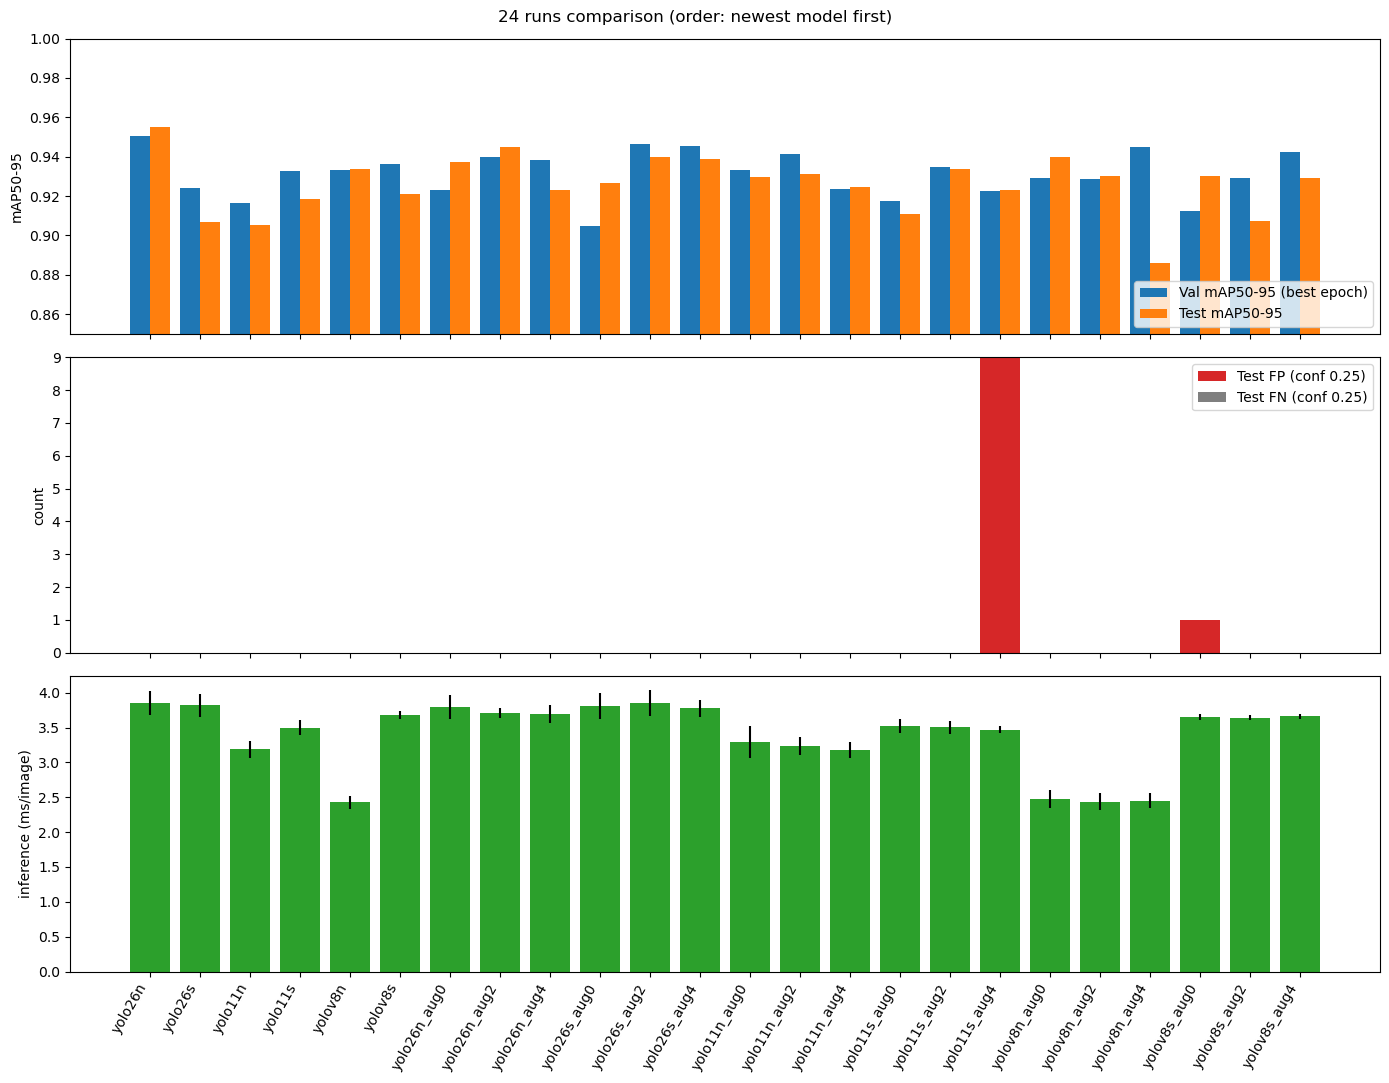

저장: /home/mu-01/ROKEY_mP4_A1/rokey_ws/src/wc/03_YOLO_v8_object_detection/result_detection/test_eval


In [12]:
import re
import numpy as np

TEST_DIR = RESULT_DIR / 'test_eval'
TEST_DIR.mkdir(exist_ok=True)
CONF_TEST, NMS_IOU, MATCH_IOU = 0.25, 0.7, 0.5
OP_CONF = 0.8            # 웹캠 publisher 운용 conf (참고 집계용)
WARMUP, REPEAT = 5, 3
test_images = sorted((DATA_DIR / 'test/images').glob('*.jpg'))

# 모든 run 목록 (표·그래프 순서: MODEL_LIST 순서, 실험 1 → 실험 2)
RUNS = [('exp1', m, 'default', EXP1_DIR / m) for m in MODEL_LIST]
RUNS += [('exp2', m, a, EXP2_DIR / f'{m}_{a}') for m in MODEL_LIST for a in AUG_SETTINGS]


def load_gt(img_path, w, h):
    # YOLO 라벨(정규화 xywh)을 픽셀 xyxy로 바꾼다
    gt = []
    for line in (img_path.parent.parent / 'labels' / (img_path.stem + '.txt')).read_text().splitlines():
        if line.strip():
            c, cx, cy, bw, bh = map(float, line.split())
            gt.append((int(c), [(cx - bw / 2) * w, (cy - bh / 2) * h, (cx + bw / 2) * w, (cy + bh / 2) * h]))
    return gt


def box_iou(a, b):
    ix = max(0, min(a[2], b[2]) - max(a[0], b[0]))
    iy = max(0, min(a[3], b[3]) - max(a[1], b[1]))
    inter = ix * iy
    union = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter
    return inter / union if union > 0 else 0.0


def match(preds, gts):
    # 같은 class끼리 IoU 큰 쌍부터 일대일 매칭. preds: [(cls, conf, box)], gts: [(cls, box)]
    pairs = sorted(((box_iou(p[2], g[1]), i, j) for i, p in enumerate(preds) for j, g in enumerate(gts)
                    if p[0] == g[0]), reverse=True)
    used_p, used_g, tp = set(), set(), []
    for iou, i, j in pairs:
        if iou < MATCH_IOU:
            break
        if i not in used_p and j not in used_g:
            used_p.add(i); used_g.add(j); tp.append((i, j, iou))
    return tp, used_p, used_g


# 학습 log에서 run별 실제 optimizer 읽기 (run 순서대로 'optimizer: AdamW(lr=...)' 줄이 나온다)
opt_lines = []
for f in sorted(LOG_DIR.glob('log_*.txt')):
    text = re.sub(r'\x1b\[[0-9;]*m', '', f.read_text(encoding='utf-8', errors='ignore'))
    opt_lines += re.findall(r'optimizer: (\w+\(lr=[0-9.]+, momentum=[0-9.]+\))', text)
print('log에서 찾은 optimizer 줄:', len(opt_lines), '/', set(opt_lines))

summary, det_rows, speed_rows = [], [], []
for exp, model_name, aug, run_dir in RUNS:
    run = run_dir.name
    best = run_dir / 'weights' / 'best.pt'
    hist = pd.read_csv(run_dir / 'results.csv')
    # best.pt는 저장 시 epoch 정보가 지워지므로, Ultralytics fitness(= mAP50-95)가 처음 최고인 epoch로 구한다
    best_epoch = int(hist['metrics/mAP50-95(B)'].values.argmax()) + 1
    model = YOLO(str(best))

    # 1) Test 집계
    cnt = {n: dict(gt=0, tp=0, fp=0, fn=0) for n in names}
    tp_conf = []
    for img in test_images:
        r = model.predict(str(img), conf=CONF_TEST, iou=NMS_IOU, imgsz=IMGSZ, verbose=False)[0]
        h, w = r.orig_shape
        gts = load_gt(img, w, h)
        preds = [(int(c), float(cf), b.tolist()) for c, cf, b in
                 zip(r.boxes.cls.cpu(), r.boxes.conf.cpu(), r.boxes.xyxy.cpu())]
        tp, used_p, used_g = match(preds, gts)
        tp_iou = {i: iou for i, j, iou in tp}
        for c, _ in gts:
            cnt[names[c]]['gt'] += 1
        for i, (c, cf, b) in enumerate(preds):
            ok = i in used_p
            cnt[names[c]]['tp' if ok else 'fp'] += 1
            if ok:
                tp_conf.append(cf)
            det_rows.append(dict(run=run, image=img.name, cls=names[c], conf=round(cf, 4),
                                 matched=ok, iou=round(tp_iou.get(i, 0.0), 3)))
        for j, (c, b) in enumerate(gts):
            if j not in used_g:
                cnt[names[c]]['fn'] += 1
                det_rows.append(dict(run=run, image=img.name, cls=names[c], conf=None, matched='FN', iou=None))

    # 2) 처리 시간 (워밍업 5회 → 전체 3회 반복)
    for _ in range(WARMUP):
        model.predict(str(test_images[0]), conf=CONF_TEST, iou=NMS_IOU, imgsz=IMGSZ, verbose=False)
    for rep in range(REPEAT):
        for img in test_images:
            sp = model.predict(str(img), conf=CONF_TEST, iou=NMS_IOU, imgsz=IMGSZ, verbose=False)[0].speed
            speed_rows.append(dict(run=run, rep=rep, image=img.name, pre_ms=sp['preprocess'],
                                   inf_ms=sp['inference'], post_ms=sp['postprocess']))
    sp = pd.DataFrame([s for s in speed_rows if s['run'] == run])

    # 3) Test mAP (Ultralytics val, split='test')
    tm = model.val(data=str(DATA_YAML), imgsz=IMGSZ, batch=BATCH, split='test', plots=False, verbose=False,
                   project=str(run_dir), name='test_best', exist_ok=True)

    tot = {k: sum(v[k] for v in cnt.values()) for k in ['gt', 'tp', 'fp', 'fn']}
    # 운용 기준 conf 0.8 (웹캠 publisher 설정)에서의 결과: 0.25 매칭 결과에서 conf 0.8 이상만 남긴다
    d = pd.DataFrame([r for r in det_rows if r['run'] == run])
    d08 = d[d['conf'].notna() & (d['conf'].astype(float) >= OP_CONF)]
    car_tp08 = int(((d08['cls'] == 'car') & (d08['matched'] == True)).sum())
    summary.append(dict(
        exp=exp, model=model_name, aug=aug, run=run,
        best_epoch=best_epoch, last_epoch=len(hist), train_min=round(hist['time'].iloc[-1] / 60, 2),
        val_mAP50=round(hist.loc[best_epoch - 1, 'metrics/mAP50(B)'], 4) if best_epoch > 0 else None,
        val_mAP50_95=round(hist.loc[best_epoch - 1, 'metrics/mAP50-95(B)'], 4) if best_epoch > 0 else None,
        test_mAP50=round(tm.box.map50, 4), test_mAP50_95=round(tm.box.map, 4),
        test_GT=tot['gt'], test_TP=tot['tp'], test_FP=tot['fp'], test_FN=tot['fn'],
        car_TP=cnt['car']['tp'], car_FP=cnt['car']['fp'], car_FN=cnt['car']['fn'],
        dummy_TP=cnt['dummy']['tp'], dummy_FP=cnt['dummy']['fp'], dummy_FN=cnt['dummy']['fn'],
        car_FN_conf08=cnt['car']['gt'] - car_tp08,
        FP_conf08=int((d08['matched'] == False).sum()),
        tp_conf_mean=round(float(np.mean(tp_conf)), 4) if tp_conf else None,
        inf_mean=round(sp['inf_ms'].mean(), 3), inf_std=round(sp['inf_ms'].std(), 3),
        inf_p95=round(sp['inf_ms'].quantile(0.95), 3),
        pre_mean=round(sp['pre_ms'].mean(), 3), post_mean=round(sp['post_ms'].mean(), 3),
        total_mean=round((sp['pre_ms'] + sp['inf_ms'] + sp['post_ms']).mean(), 3),
    ))
    print(f"{run:16s} best_ep {best_epoch:3d} | TP/FP/FN {tot['tp']}/{tot['fp']}/{tot['fn']} | inf {summary[-1]['inf_mean']} ms")
    del model
    gc.collect()
    torch.cuda.empty_cache()

final = pd.DataFrame(summary)
if len(opt_lines) == len(final):
    final.insert(4, 'optimizer', opt_lines)
final.to_csv(TEST_DIR / 'final_comparison.csv', index=False)
pd.DataFrame(det_rows).to_csv(TEST_DIR / 'test_detections.csv', index=False)
pd.DataFrame(speed_rows).to_csv(TEST_DIR / 'speed_samples.csv', index=False)
display(final)

# 24개 run 비교 그래프: Val / Test mAP50-95, Test 오류 수, 평균 추론 시간
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
x = np.arange(len(final))
axes[0].bar(x - 0.2, final['val_mAP50_95'], 0.4, label='Val mAP50-95 (best epoch)')
axes[0].bar(x + 0.2, final['test_mAP50_95'], 0.4, label='Test mAP50-95')
axes[0].set_ylim(0.85, 1.0); axes[0].legend(loc='lower right'); axes[0].set_ylabel('mAP50-95')
axes[1].bar(x, final['test_FP'], label='Test FP (conf 0.25)', color='tab:red')
axes[1].bar(x, final['test_FN'], bottom=final['test_FP'], label='Test FN (conf 0.25)', color='tab:gray')
axes[1].legend(); axes[1].set_ylabel('count')
axes[2].bar(x, final['inf_mean'], yerr=final['inf_std'], color='tab:green')
axes[2].set_ylabel('inference (ms/image)')
axes[2].set_xticks(x); axes[2].set_xticklabels(final['run'], rotation=60, ha='right')
plt.suptitle('24 runs comparison (order: newest model first)')
plt.tight_layout()
plt.savefig(TEST_DIR / 'comparison.png')
plt.show()
print('저장:', TEST_DIR)

## 9. 선정 모델 상세 분석
위 비교로 고른 모델 1개를 **별도 Validation**(그래프 포함)으로 다시 평가하고, class별 AP를 기록한다.
결과: `result_detection/selected/<run>/validation/` (confusion matrix, Box F1/P/R/PR 곡선)

In [13]:
# ⚠️ 선정 모델 경로 (8번 비교 결과를 보고 정함)
SELECTED_RUN = EXP1_DIR / 'yolo26n'

SEL_DIR = RESULT_DIR / 'selected' / SELECTED_RUN.name
model = YOLO(str(SELECTED_RUN / 'weights' / 'best.pt'))
m = model.val(data=str(DATA_YAML), imgsz=IMGSZ, batch=BATCH, split='val', conf=0.001, iou=0.7,
              project=str(SEL_DIR), name='validation', exist_ok=True, plots=True)

per_class = pd.DataFrame({
    'class': [names[i] for i in m.box.ap_class_index],
    'P': m.box.p.round(4), 'R': m.box.r.round(4),
    'AP50': m.box.ap50.round(4), 'AP50-95': m.box.ap.round(4),
})
display(per_class)
per_class.to_csv(SEL_DIR / 'per_class_ap.csv', index=False)
print('Validation 요약 P / R / mAP50 / mAP50-95:',
      round(m.box.mp, 5), round(m.box.mr, 5), round(m.box.map50, 5), round(m.box.map, 5))
print('저장:', SEL_DIR / 'validation')
del model

Ultralytics 8.4.170 🚀 Python-3.12.3 torch-2.14.1+cu130 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 7806MiB)


YOLO26n summary (fused): 120 layers, 2,375,226 parameters, 0 gradients, 5.3 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2752.8±467.5 MB/s, size: 24.3 KB)


val: Scanning /home/mu-01/ROKEY_mP4_A1/rokey_ws/src/wc/data_wc/rokey_mp4_a1.v2i.yolo26/valid/labels.cache... 43 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 43/43 22.5Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 33% ━━━━──────── 1/3 1.0it/s 0.3s<1.9s

...

                 dummy         35         35      0.992          1      0.995      0.962


Speed: 2.0ms preprocess, 2.2ms inference, 0.0ms loss, 0.4ms postprocess per image


Results saved to /home/mu-01/ROKEY_mP4_A1/rokey_ws/src/wc/03_YOLO_v8_object_detection/result_detection/selected/yolo26n/validation


,class,P,R,AP50,AP50-95
0,car,0.9716,1.0,0.9945,0.9278
1,dummy,0.9921,1.0,0.9950,0.9622


Validation 요약 P / R / mAP50 / mAP50-95: 0.98185 1.0 0.99473 0.94499
저장: /home/mu-01/ROKEY_mP4_A1/rokey_ws/src/wc/03_YOLO_v8_object_detection/result_detection/selected/yolo26n/validation


## 10. 결과물 위치 정리
```
result_detection/
├── custom_data.yaml          # 절대 경로 데이터셋 yaml
├── pretrained/               # COCO 사전학습 가중치 (자동 다운로드)
├── log/log_<시각>.txt        # Ultralytics 학습 log
├── exp1_models/<모델>/        # 실험 1 학습 결과 (weights/best.pt, results.csv, 그래프)
├── exp2_aug/<모델>_<조건>/    # 실험 2 학습 결과
├── compare_models.csv / .png # 실험 1 비교표 / 그래프
├── compare_aug.csv           # 실험 2 전체 비교표
├── compare_aug_map.csv / .png# 실험 2 모델 x 증강 mAP50-95 표 / 그래프
├── predict_test/<run>/       # test 이미지 검출 결과
├── test_eval/                # Test 고정 기준 집계, 처리 시간 (24개 run)
└── selected/<run>/validation/# 선정 모델 별도 Validation (그래프 포함)
```
`QUICK_TEST = True`로 돌린 결과는 `result_detection/_quick_test/` 아래에 같은 구조로 저장된다 (확인 후 지워도 됨).